In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [2]:
# mcds_path = '/ceph/MethDev/pbio/kay/data/Arab10_All_mcds.mcds'
mcds_path = '/ceph/MethDev/pbio/All_mcds.mcds'
rna_path = '/ceph/MethDev/pbio/Arab6_RNA_normalized_data.csv'
meta_path ='/ceph/MethDev/pbio/data/Arab6_cells_and_clusters.csv'
seurat_path = '/ceph/MethDev/pbio/0523_seurat_metadata.csv'

In [3]:
mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna_matrix = pd.read_csv(rna_path,index_col = 0).T
meta = pd.read_csv(meta_path)
sig_gene = pd.read_csv('/ceph/MethDev/clusters/new_gene_list.txt', header = None)
#re-format and combine clusters
meta['Cell'] = meta['Cell'].str.replace('.','-')
meta = meta.set_index('Cell')
# meta['Cluster'] = meta['Cluster'].replace({6:1,0:1,4:1,5:3})
seurat = pd.read_csv(seurat_path).set_index('Unnamed: 0')

In [4]:
sig_gene

,0
0,AT1G01410
1,AT1G01550
2,AT1G02110
3,AT1G02260
4,AT1G03140
...,...
1275,ATMG01390
1276,ATMG01400
1277,ATMG01410
1278,ATMG09960


In [20]:
sig_gene_methlypy = pd.read_csv('/ceph/MethDev/clusters/ids.txt', sep='\t', header=None)

In [21]:
sig_gene_methlypy

,0
0,AT1G29540
1,AT1G29910
2,AT1G30540
3,AT1G32450
4,AT1G32520
...,...
142,AT5G20050
143,AT5G24210
144,AT5G25140
145,AT5G27120


In [5]:
sd = seurat[seurat['condition']=='Acute Stress']
ww = seurat[seurat['condition']=='Normal']


ww_mc = mCGN_mc.reindex(ww.index)
ww_cov = mCGN_cov.reindex(ww.index)
sd_mc = mCGN_mc.reindex(sd.index)
sd_cov = mCGN_cov.reindex(sd.index)
ww_rna = rna_matrix.reindex(ww.index)
sd_rna = rna_matrix.reindex(sd.index)

NameError: name 'mCGN_mc' is not defined

In [6]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()

mCGN_mc_sd = mCGN_mc.loc[sd.index]
mCGN_mc_ww = mCGN_mc.loc[ww.index]

mCGN_cov_sd = mCGN_cov.loc[sd.index]
mCGN_cov_ww = mCGN_cov.loc[ww.index]


mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)
mCGN_frac

mCGN_frac_sd = mCGN_mc_sd.div(mCGN_cov_sd).fillna(0)

mCGN_frac_ww = mCGN_mc_ww.div(mCGN_cov_ww).fillna(0)


In [7]:
#filter out ATM and ATC genes, then aggregate via sum per cluster
filtered_columns = [col for col in mCGN_mc.columns if 'ATM' not in col and 'ATC' not in col and 'cluster' not in col]

mCGN_mc['cluster'] = meta['Cluster']
mCGN_mc_sd['cluster'] = meta['Cluster']
mCGN_mc_ww['cluster'] = meta['Cluster']

mCGN_cov['cluster'] = meta['Cluster']
mCGN_cov_sd['cluster'] = meta['Cluster']
mCGN_cov_ww['cluster'] = meta['Cluster']


mCGN_mc_by_cluster = mCGN_mc.groupby('cluster').sum()[filtered_columns]

mCGN_mc_sd_by_cluster = mCGN_mc_sd.groupby('cluster').sum()[filtered_columns]
mCGN_mc_ww_by_cluster = mCGN_mc_ww.groupby('cluster').sum()[filtered_columns]

mCGN_cov_by_cluster = mCGN_cov.groupby('cluster').sum()[filtered_columns]

mCGN_cov_sd_by_cluster = mCGN_cov_sd.groupby('cluster').sum()[filtered_columns]
mCGN_cov_ww_by_cluster = mCGN_cov_ww.groupby('cluster').sum()[filtered_columns]


In [8]:
mCGN_frac_by_cluster = mCGN_mc_by_cluster.div(mCGN_cov_by_cluster).fillna(0)
mCGN_frac_by_cluster

mCGN_frac_sd_by_cluster = mCGN_mc_sd_by_cluster.div(mCGN_cov_sd_by_cluster).fillna(0)
mCGN_frac_ww_by_cluster = mCGN_mc_ww_by_cluster.div(mCGN_cov_ww_by_cluster).fillna(0)

In [9]:
#filter by methylation mean
mCGN_frac_by_cluster = mCGN_frac_by_cluster.loc[:,mCGN_frac_by_cluster.mean(axis=0)>0.03]

mCGN_frac_sd_by_cluster = mCGN_frac_sd_by_cluster.loc[:,mCGN_frac_sd_by_cluster.mean(axis=0)>0.03]
mCGN_frac_ww_by_cluster = mCGN_frac_ww_by_cluster.loc[:,mCGN_frac_ww_by_cluster.mean(axis=0)>0.03]

In [23]:
# Create a list of significant genes
sig_gene_list = sig_gene_methlypy[0].tolist()

# Subset the original DataFrame to include only the columns for the significant genes
sig_gene_overlap_df = mCGN_frac_by_cluster.loc[:, mCGN_frac_by_cluster.columns.isin(sig_gene_list)]

sig_gene_overlap_df

sig_gene_overlap_sd = mCGN_frac_sd_by_cluster.loc[:, mCGN_frac_sd_by_cluster.columns.isin(sig_gene_list)]
sig_gene_overlap_ww = mCGN_frac_ww_by_cluster.loc[:, mCGN_frac_ww_by_cluster.columns.isin(sig_gene_list)]
sig_gene_overlap_df

gene,AT1G02110,AT1G06730,AT1G09160,AT1G11300,AT1G11860,AT1G14560,AT1G14710,AT1G20470,AT1G21980,AT1G23030,...,AT5G56490,AT5G57710,AT5G58520,AT5G58570,AT5G60210,AT5G61070,AT5G62030,AT5G65010,AT5G66520,AT5G67385
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.192462,0.080402,0.060198,0.300621,0.056583,0.155155,0.146557,0.082062,0.151938,0.268634,...,0.081666,0.150948,0.107652,0.134972,0.235145,0.144683,0.147620,0.165718,0.213660,0.207325
1.0,0.173191,0.079250,0.065128,0.291477,0.049951,0.158288,0.169936,0.081497,0.143419,0.265411,...,0.077236,0.145529,0.107027,0.130557,0.219281,0.144365,0.128993,0.111238,0.216381,0.199668
2.0,0.188358,0.107066,0.053329,0.339767,0.101587,0.175008,0.176562,0.234888,0.168633,0.276145,...,0.100831,0.157763,0.117370,0.183792,0.236445,0.226791,0.178440,0.188239,0.169639,0.216643
3.0,0.054003,0.163708,0.168404,0.203120,0.207052,0.092633,0.252609,0.361849,0.079155,0.212038,...,0.027856,0.107985,0.158299,0.329412,0.178834,0.228930,0.186374,0.185304,0.331519,0.094606
4.0,0.202826,0.095404,0.064784,0.358482,0.069010,0.170995,0.165064,0.196757,0.153485,0.287311,...,0.087435,0.129571,0.128485,0.149156,0.248814,0.172115,0.136234,0.187799,0.190386,0.228042
5.0,0.023550,0.159175,0.153360,0.199820,0.216082,0.051078,0.264382,0.360877,0.037226,0.244703,...,0.018148,0.103718,0.156718,0.325031,0.161272,0.220386,0.191724,0.229267,0.350337,0.116910
6.0,0.180348,0.084893,0.073563,0.308230,0.116019,0.174253,0.165868,0.226481,0.177651,0.259191,...,0.073040,0.135524,0.110427,0.190818,0.250678,0.210273,0.132377,0.131541,0.256203,0.188767
7.0,0.192500,0.179651,0.172638,0.332600,0.220420,0.172060,0.243077,0.339901,0.144343,0.271886,...,0.076264,0.107931,0.154419,0.270217,0.214321,0.219289,0.217683,0.204042,0.360665,0.304369
8.0,0.191176,0.099274,0.120104,0.332582,0.147959,0.185204,0.237147,0.247525,0.096189,0.238449,...,0.088210,0.136227,0.092189,0.262000,0.215896,0.200813,0.201529,0.174987,0.241040,0.175227


In [24]:
shared_frac = (sig_gene_overlap_df.shape[1]/len(sig_gene),sig_gene_overlap_sd.shape[1]/len(sig_gene),sig_gene_overlap_ww.shape[1]/len(sig_gene))
shared_frac 

(0.1125, 0.1125, 0.1125)

In [12]:
rna_matrix['Cluster'] = meta['Cluster']

rna_by_cluster = rna_matrix.groupby('Cluster').mean()
rna_by_cluster

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [13]:
sd

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.5,seurat_clusters,cell_id,condition
Unnamed: 0,,,,,,,,
NJ_221007_P1-2-K15-J3,NJ,704365,4028,0,0,0,NJ_221007_P1-2-K15-J3,Acute Stress
NJ_221007_P1-2-K15-E16,NJ,169386,1628,0,9,9,NJ_221007_P1-2-K15-E16,Acute Stress
NJ_221007_P1-2-K15-C15,NJ,331484,2471,0,0,0,NJ_221007_P1-2-K15-C15,Acute Stress
NJ_221007_P1-2-K15-J4,NJ,705364,4407,0,6,6,NJ_221007_P1-2-K15-J4,Acute Stress
NJ_221007_P1-2-K15-M16,NJ,653935,3356,0,0,0,NJ_221007_P1-2-K15-M16,Acute Stress
...,...,...,...,...,...,...,...,...
NJ_221007_P3-1-C21-J1,NJ,357492,2291,0,5,5,NJ_221007_P3-1-C21-J1,Acute Stress
NJ_221007_P3-1-C21-A13,NJ,128540,1931,0,0,0,NJ_221007_P3-1-C21-A13,Acute Stress
NJ_221007_P3-1-C21-K14,NJ,289656,2028,0,4,4,NJ_221007_P3-1-C21-K14,Acute Stress


In [14]:
ww

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.5,seurat_clusters,cell_id,condition
Unnamed: 0,,,,,,,,
NJ_221007_P6-5-I2-P10,NJ,180891,2057,0,3,3,NJ_221007_P6-5-I2-P10,Normal
NJ_221007_P6-5-I2-F22,NJ,160035,1700,0,1,1,NJ_221007_P6-5-I2-F22,Normal
NJ_221007_P6-5-I2-B9,NJ,140260,1253,0,2,2,NJ_221007_P6-5-I2-B9,Normal
NJ_221007_P6-5-I2-F9,NJ,205952,1807,0,2,2,NJ_221007_P6-5-I2-F9,Normal
NJ_221007_P6-5-I2-K22,NJ,365536,2566,0,1,1,NJ_221007_P6-5-I2-K22,Normal
...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,NJ,4853,688,0,2,2,NJ_221007_P8-5-G10-N10,Normal
NJ_221007_P8-5-G10-F22,NJ,10311,1438,0,1,1,NJ_221007_P8-5-G10-F22,Normal
NJ_221007_P8-5-G10-O10,NJ,4059,694,0,3,3,NJ_221007_P8-5-G10-O10,Normal


In [15]:
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980,Cluster
NJ_221007_P1-2-K15-J3,0,0,0,44,0,69,0,0,0,0,...,20,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-E16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12
NJ_221007_P1-2-K15-C15,0,0,0,3,0,110,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P1-2-K15-J4,0,78,0,623,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-M16,0,3,0,36,0,28,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
NJ_221007_P8-5-G10-N21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [25]:
corr_values = sig_gene_overlap_df.corrwith(rna_by_cluster, axis =0).dropna()
corr_values.to_csv('corr_values.csv', header=True)


In [26]:
corr_values

AT1G02110   -0.737955
AT1G06730   -0.192204
AT1G09160   -0.626691
AT1G11300   -0.112545
AT1G11860   -0.639541
               ...   
AT5G60210   -0.790336
AT5G61070   -0.636885
AT5G62030   -0.100033
AT5G65010   -0.709622
AT5G67385   -0.408422
Length: 138, dtype: float64

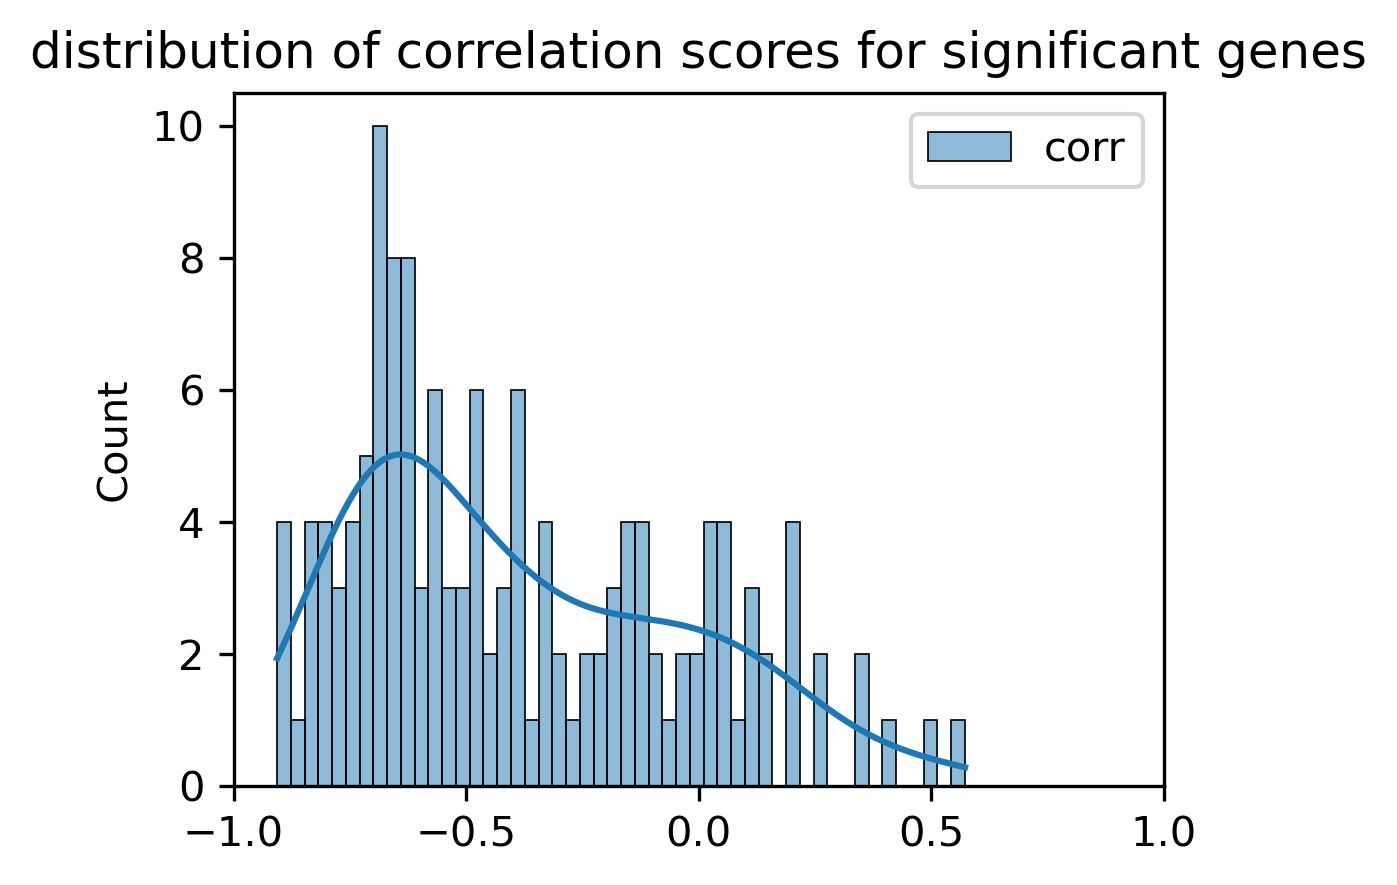

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Assuming corr_values is a numpy array or pandas Series with your correlation values
# corr_values = ...

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_values, ax=ax, kde=True, bins=50, label='corr')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

ax.set_title('distribution of correlation scores for significant genes')

# Set x-axis limits
ax.set_xlim(-1, 1)

# # Add legend
ax.legend()

# Show or save the figure
fig.savefig(f'/ceph/MethDev/pbio/kay/figures/0620_new_sig_mc_rna_correlation.pdf', bbox_inches='tight')
plt.show()


In [28]:
df = sig_gene_overlap_df
# Get the column names
columns = list(df.columns)

# Shuffle the columns
shuffled_columns = np.random.permutation(columns)

# Create a new DataFrame with shuffled columns while maintaining the order of values
shuffled_df = pd.DataFrame({columns[i]: df[shuffled_columns[i]].values for i in range(len(columns))})

# Print shuffled DataFrame
print("\nShuffled DataFrame:")
shuffled_df


Shuffled DataFrame:


,AT1G02110,AT1G06730,AT1G09160,AT1G11300,AT1G11860,AT1G14560,AT1G14710,AT1G20470,AT1G21980,AT1G23030,...,AT5G56490,AT5G57710,AT5G58520,AT5G58570,AT5G60210,AT5G61070,AT5G62030,AT5G65010,AT5G66520,AT5G67385
0,0.068801,0.167664,0.142991,0.268634,0.130093,0.431417,0.194011,0.033476,0.146557,0.083994,...,0.103955,0.352719,0.213660,0.106418,0.031943,0.089911,0.262976,0.256887,0.026156,0.093426
1,0.052864,0.144971,0.150007,0.265411,0.115631,0.414937,0.162155,0.039879,0.169936,0.080065,...,0.111756,0.286687,0.216381,0.082958,0.027785,0.085372,0.236393,0.261818,0.023152,0.088395
2,0.122581,0.173290,0.138351,0.276145,0.197119,0.419120,0.223920,0.063108,0.176562,0.128344,...,0.115309,0.374777,0.169639,0.147252,0.075762,0.152000,0.258328,0.286160,0.032754,0.096664
3,0.261788,0.169106,0.087994,0.212038,0.209266,0.272025,0.075526,0.060159,0.252609,0.017271,...,0.055852,0.607567,0.331519,0.270945,0.020609,0.250223,0.617682,0.124559,0.069983,0.202735
4,0.069793,0.172385,0.154162,0.287311,0.143447,0.434213,0.196402,0.063307,0.165064,0.108602,...,0.100867,0.350599,0.190386,0.131982,0.064942,0.092933,0.279578,0.254072,0.027163,0.104920
5,0.205148,0.186155,0.104859,0.244703,0.218622,0.265594,0.048825,0.085561,0.264382,0.016879,...,0.058590,0.686670,0.350337,0.315567,0.012149,0.213089,0.617238,0.141788,0.090496,0.199923
6,0.112532,0.118205,0.169059,0.259191,0.167993,0.412841,0.197713,0.054858,0.165868,0.091199,...,0.099675,0.398614,0.256203,0.116421,0.075796,0.214345,0.356040,0.225011,0.035027,0.077819
7,0.305990,0.104446,0.147823,0.271886,0.246642,0.409861,0.175538,0.087912,0.243077,0.057054,...,0.094474,0.654346,0.360665,0.225202,0.041651,0.306701,0.650845,0.333560,0.083603,0.210283
8,0.167568,0.164443,0.121164,0.238449,0.192517,0.425443,0.199190,0.063942,0.237147,0.077987,...,0.121642,0.483773,0.241040,0.148649,0.075439,0.227838,0.344795,0.277127,0.043515,0.078279
9,0.088235,0.072917,0.171821,0.174699,0.252381,0.517572,0.252427,0.032258,0.191667,0.065476,...,0.080000,0.515625,0.206349,0.293706,0.048632,0.166667,0.323810,0.229050,0.026042,0.115607


In [29]:
rand_corr_values = shuffled_df.corrwith(rna_by_cluster, axis =0).dropna()
rand_corr_values

AT1G02110    0.336713
AT1G06730   -0.095721
AT1G09160   -0.214593
AT1G11300    0.084747
AT1G11860   -0.759555
               ...   
AT5G60210   -0.527665
AT5G61070   -0.477646
AT5G62030   -0.289977
AT5G65010   -0.082212
AT5G67385   -0.613267
Length: 138, dtype: float64

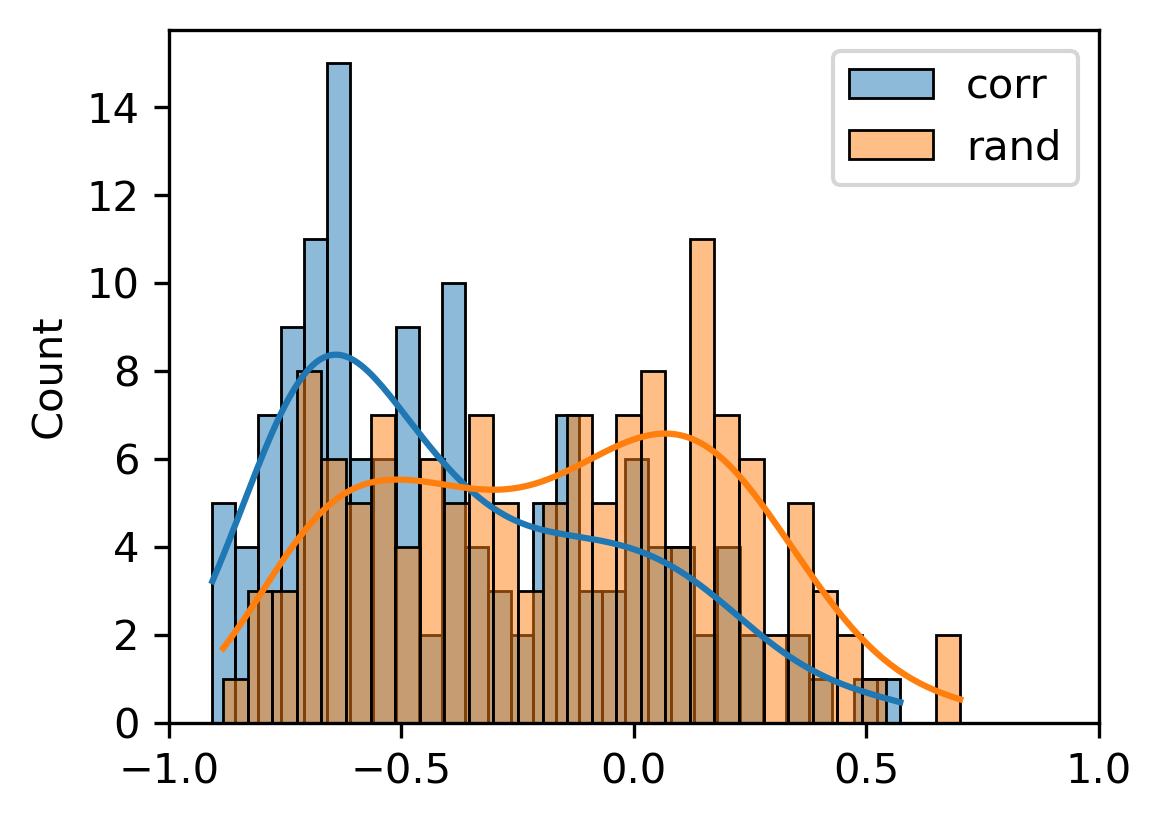

In [30]:

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_values, ax=ax, kde=True, bins=30, label='corr')
sns.histplot(rand_corr_values, ax=ax, kde=True, bins=30, label='rand')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

# Set x-axis limits
ax.set_xlim(-1, 1)

# Add legend
ax.legend()

# Show or save the figure
fig.savefig(f'/ceph/MethDev/pbio/kay/figures/0620_new_gene_rand_mc_rna_correlation.pdf', bbox_inches='tight')
plt.show()


In [31]:
ordered_corr = corr_values.sort_values(ascending = False)

In [32]:
pos = ordered_corr[:5]
pos.index

Index(['AT1G69360', 'AT4G28650', 'AT5G58570', 'AT5G05590', 'AT3G20080'], dtype='object')

In [33]:
neg = ordered_corr[-5:]
neg

AT3G23450   -0.858379
AT3G55800   -0.880832
AT1G62030   -0.886872
AT4G30400   -0.904946
AT2G33060   -0.906197
dtype: float64

In [34]:
sig_gene_overlap_df[pos.index]

gene,AT1G69360,AT4G28650,AT5G58570,AT5G05590,AT3G20080
cluster,,,,,
0.0,0.299214,0.167664,0.134972,0.068801,0.080803
1.0,0.284776,0.144971,0.130557,0.052864,0.079397
2.0,0.308465,0.173290,0.183792,0.122581,0.111111
3.0,0.363258,0.169106,0.329412,0.261788,0.136238
4.0,0.270724,0.172385,0.149156,0.069793,0.100373
5.0,0.357438,0.186155,0.325031,0.205148,0.136967
6.0,0.320733,0.118205,0.190818,0.112532,0.096603
7.0,0.375382,0.104446,0.270217,0.305990,0.140550
8.0,0.344368,0.164443,0.262000,0.167568,0.136197


In [35]:
rna_by_cluster[pos.index]

,AT1G69360,AT4G28650,AT5G58570,AT5G05590,AT3G20080
Cluster,,,,,
0,21.328647,0.147627,0.008787,0.115993,3.483304
1,58.660622,0.036269,0.005181,0.259067,7.992228
2,15.683140,0.226744,0.002907,0.130814,2.017442
3,49.643312,0.012739,0.012739,0.433121,19.315287
4,30.802432,0.021277,0.079027,0.860182,1.352584
5,55.841837,0.954082,0.000000,0.540816,8.724490
6,40.892655,0.067797,0.101695,1.067797,3.112994
7,68.784810,0.126582,0.088608,1.911392,11.620253
8,20.992481,0.285714,0.022556,0.007519,2.255639


In [36]:
rem_14_mc = sig_gene_overlap_df.loc[:13, :]

In [37]:
rem_14_rna = rna_by_cluster.loc[:13, :]
rem_14_rna

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.377856,30.949033,9.337434,51.249561,0.0,24.173989,236.629174,0.014060,15.038664,9.994728,...,0.022847,0.906854,0.003515,0.026362,0.0,0.0,0.005272,0.000000,0.007030,0.000000
1,3.427461,56.386010,16.386010,78.549223,0.0,48.961140,297.917098,0.233161,35.730570,12.906736,...,0.103627,1.093264,0.020725,0.025907,0.0,0.0,0.002591,0.000000,0.023316,0.015544
2,0.037791,15.168605,8.904070,27.770349,0.0,7.360465,63.476744,0.005814,7.709302,2.101744,...,0.046512,0.584302,0.000000,0.000000,0.0,0.0,0.203488,0.014535,0.008721,0.005814
3,0.929936,34.477707,5.878981,39.506369,0.0,6.152866,83.181529,0.038217,15.863057,9.687898,...,0.025478,1.082803,0.022293,0.006369,0.0,0.0,0.015924,0.000000,0.000000,0.003185
4,2.313070,41.820669,8.835866,32.340426,0.0,11.702128,93.541033,0.048632,14.635258,4.176292,...,0.015198,0.787234,0.006079,0.003040,0.0,0.0,0.006079,0.000000,0.003040,0.003040
5,0.647959,17.770408,0.464286,34.061224,0.0,4.556122,71.239796,0.974490,5.683673,10.770408,...,0.010204,0.591837,0.045918,0.000000,0.0,0.0,0.071429,0.000000,0.005102,0.015306
6,1.361582,67.073446,3.627119,26.548023,0.0,26.491525,86.350282,0.045198,37.610169,16.655367,...,0.101695,1.406780,0.022599,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.062147
7,11.107595,33.322785,4.727848,32.734177,0.0,16.993671,68.582278,5.284810,5.677215,8.139241,...,0.018987,1.424051,0.012658,0.012658,0.0,0.0,0.037975,0.000000,0.006329,0.006329
8,0.917293,44.932331,10.789474,42.120301,0.0,5.676692,78.849624,0.045113,11.548872,8.924812,...,0.037594,0.518797,0.037594,0.037594,0.0,0.0,0.060150,0.090226,0.015038,0.015038


In [38]:
corr_rm_14 = rem_14_mc.corrwith(rem_14_rna, axis =0).dropna()
corr_rm_14

AT1G02110   -0.766001
AT1G06730   -0.212733
AT1G09160   -0.542046
AT1G11300   -0.098178
AT1G11860   -0.623310
               ...   
AT5G60210   -0.840555
AT5G61070   -0.633297
AT5G62030   -0.161728
AT5G65010   -0.687750
AT5G67385   -0.297238
Length: 138, dtype: float64

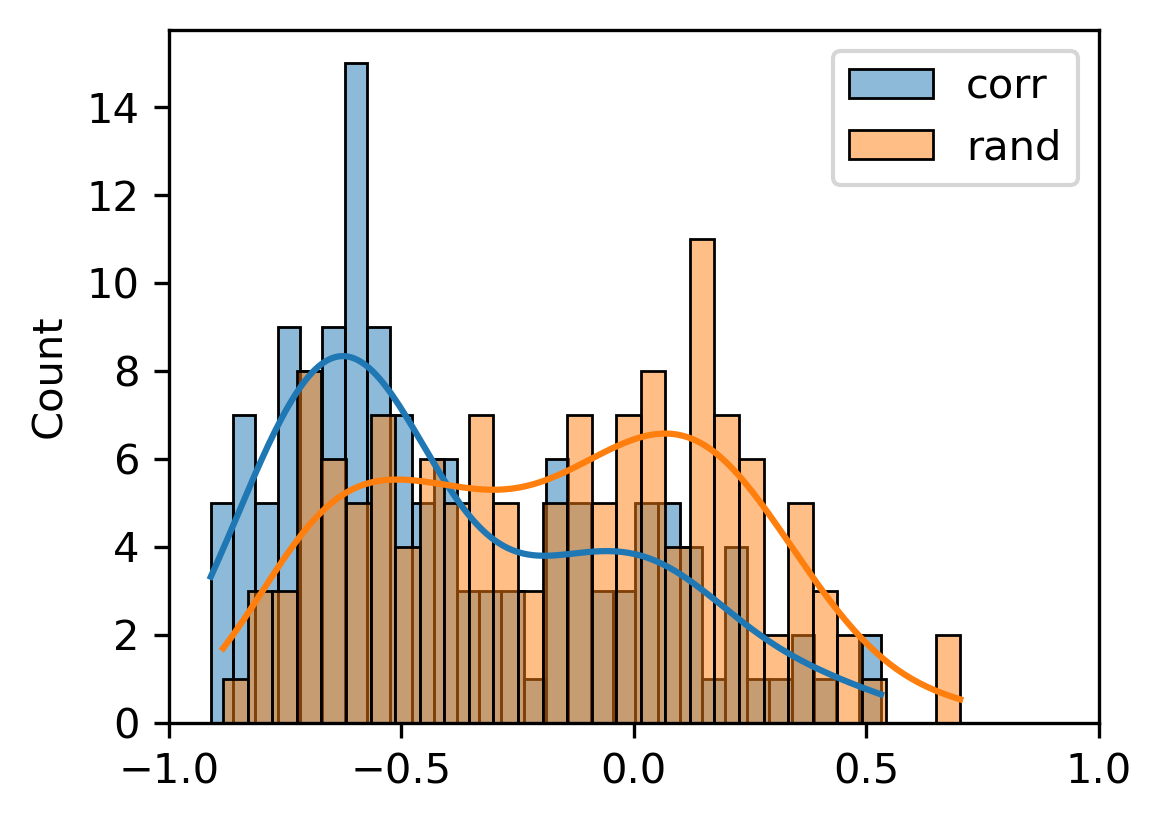

In [39]:

# Create the plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Plot the histogram with KDE
sns.histplot(corr_rm_14, ax=ax, kde=True, bins=30, label='corr')
sns.histplot(rand_corr_values, ax=ax, kde=True, bins=30, label='rand')

# Calculate mean and standard deviation for the normal distribution
data_mean = 0
data_std = corr_values.std()

# Generate x values for the normal distribution plot
x = np.linspace(-1, 1, 100)

# Generate y values using the normal distribution PDF
y = norm.pdf(x, data_mean, data_std)

# Normalize the normal distribution curve to match the histogram height
hist_height = np.histogram(corr_values, bins=50)[0].max()
y_scaled = y * hist_height / y.max()

# Plot the normal distribution curve
# ax.plot(x, y_scaled, 'r--', label='Normal distribution')

# Set x-axis limits
ax.set_xlim(-1, 1)

# Add legend
ax.legend()

# Show or save the figure
fig.savefig(f'/ceph/MethDev/pbio/kay/figures/0620_new_gene_rand_mc_rna_correlation_rem_14.pdf', bbox_inches='tight')
plt.show()


In [40]:
len(corr_rm_14.values>0.5)

138

In [41]:
len(corr_rm_14<-0.5)

138

In [42]:
len(corr_rm_14[corr_rm_14>0.5])

2

In [43]:
corr_rm_14[corr_rm_14<-0.5]

AT1G02110   -0.766001
AT1G09160   -0.542046
AT1G11860   -0.623310
AT1G20470   -0.579794
AT1G21980   -0.764934
               ...   
AT5G53970   -0.767796
AT5G57710   -0.615450
AT5G60210   -0.840555
AT5G61070   -0.633297
AT5G65010   -0.687750
Length: 68, dtype: float64

In [44]:
len(corr_values[corr_values>0.5])

2

In [45]:
len(corr_values[corr_values<-0.5])

65

In [46]:
thres = -0.5
below_threshold = corr_rm_14[corr_rm_14<=thres]
below_threshold

AT1G02110   -0.766001
AT1G09160   -0.542046
AT1G11860   -0.623310
AT1G20470   -0.579794
AT1G21980   -0.764934
               ...   
AT5G53970   -0.767796
AT5G57710   -0.615450
AT5G60210   -0.840555
AT5G61070   -0.633297
AT5G65010   -0.687750
Length: 68, dtype: float64

In [47]:
rem_14_neg_mc = rem_14_mc[corr_rm_14[corr_rm_14<-0.5].index]
rem_14_neg_mc

gene,AT1G02110,AT1G09160,AT1G11860,AT1G20470,AT1G21980,AT1G23310,AT1G29910,AT1G32520,AT1G42970,AT1G50460,...,AT5G20050,AT5G25140,AT5G27120,AT5G50860,AT5G51460,AT5G53970,AT5G57710,AT5G60210,AT5G61070,AT5G65010
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.192462,0.060198,0.056583,0.082062,0.151938,0.110614,0.106418,0.161783,0.033784,0.159635,...,0.031943,0.014503,0.130093,0.284177,0.093426,0.114418,0.150948,0.235145,0.144683,0.165718
1.0,0.173191,0.065128,0.049951,0.081497,0.143419,0.103230,0.082958,0.123488,0.027144,0.179059,...,0.027785,0.014368,0.115631,0.293146,0.088395,0.098045,0.145529,0.219281,0.144365,0.111238
2.0,0.188358,0.053329,0.101587,0.234888,0.168633,0.147483,0.147252,0.269826,0.057926,0.215862,...,0.075762,0.021665,0.197119,0.296648,0.096664,0.140107,0.157763,0.236445,0.226791,0.188239
3.0,0.054003,0.168404,0.207052,0.361849,0.079155,0.176471,0.270945,0.280162,0.095565,0.270047,...,0.020609,0.108301,0.209266,0.180995,0.202735,0.179362,0.107985,0.178834,0.228930,0.185304
4.0,0.202826,0.064784,0.069010,0.196757,0.153485,0.127431,0.131982,0.178571,0.045465,0.181166,...,0.064942,0.018308,0.143447,0.267035,0.104920,0.122558,0.129571,0.248814,0.172115,0.187799
5.0,0.023550,0.153360,0.216082,0.360877,0.037226,0.181710,0.315567,0.350038,0.153446,0.263590,...,0.012149,0.114784,0.218622,0.130240,0.199923,0.191549,0.103718,0.161272,0.220386,0.229267
6.0,0.180348,0.073563,0.116019,0.226481,0.177651,0.117032,0.116421,0.176362,0.052074,0.229303,...,0.075796,0.040706,0.167993,0.273965,0.077819,0.123441,0.135524,0.250678,0.210273,0.131541
7.0,0.192500,0.172638,0.220420,0.339901,0.144343,0.191727,0.225202,0.312257,0.127389,0.268714,...,0.041651,0.084772,0.246642,0.293864,0.210283,0.187656,0.107931,0.214321,0.219289,0.204042
8.0,0.191176,0.120104,0.147959,0.247525,0.096189,0.152147,0.148649,0.102107,0.084337,0.219474,...,0.075439,0.064701,0.192517,0.317345,0.078279,0.179434,0.136227,0.215896,0.200813,0.174987


In [48]:
df_zscore = rem_14_neg_mc.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
df_zscore

gene,AT1G02110,AT1G09160,AT1G11860,AT1G20470,AT1G21980,AT1G23310,AT1G29910,AT1G32520,AT1G42970,AT1G50460,...,AT5G20050,AT5G25140,AT5G27120,AT5G50860,AT5G51460,AT5G53970,AT5G57710,AT5G60210,AT5G61070,AT5G65010
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.283131,-0.998239,-1.034602,-1.222736,0.563381,-0.911064,-0.876167,-0.506746,-0.916012,-1.289053,...,-0.731432,-0.983993,-1.116642,0.248873,-0.645104,-1.129048,0.640081,0.540844,-1.306000,-0.045551
1.0,-0.019840,-0.888423,-1.127157,-1.226536,0.342963,-1.096652,-1.134993,-0.923662,-1.055691,-0.956719,...,-0.874814,-0.987135,-1.422859,0.416708,-0.748388,-1.564666,0.387116,-0.006579,-1.312808,-1.358374
2.0,0.218609,-1.151262,-0.406463,-0.195190,0.995317,0.015558,-0.425667,0.669518,-0.408112,-0.327056,...,0.779529,-0.816754,0.302643,0.482252,-0.578653,-0.445554,0.958252,0.585705,0.452754,0.497143
3.0,-1.893666,1.412283,1.065532,0.658449,-1.319685,0.744081,0.938992,0.782046,0.383755,0.599999,...,-1.122247,1.206239,0.559853,-1.682103,1.598565,0.598903,-1.365694,-1.402302,0.498570,0.426437
4.0,0.446065,-0.896066,-0.861147,-0.451569,0.603400,-0.488400,-0.594128,-0.323966,-0.670256,-0.920676,...,0.406438,-0.895135,-0.833864,-0.071929,-0.409188,-0.912471,-0.357928,1.012524,-0.718422,0.486549
5.0,-2.372436,1.077133,1.191573,0.651916,-2.404465,0.875748,1.431290,1.542784,1.601471,0.489527,...,-1.413969,1.357627,0.757960,-2.631965,1.540838,0.923175,-1.564906,-2.008322,0.315543,1.485820
6.0,0.092680,-0.700500,-0.205031,-0.251715,1.228630,-0.749755,-0.765810,-0.348021,-0.531228,-0.097092,...,0.780686,-0.372126,-0.314100,0.057760,-0.965456,-0.888974,-0.080007,1.076876,0.098934,-0.869127
7.0,0.283728,1.506607,1.252118,0.510885,0.366885,1.127526,0.434331,1.131462,1.053261,0.577190,...,-0.396672,0.656842,1.351288,0.430157,1.753494,0.819583,-1.368236,-0.177725,0.292052,0.877971
8.0,0.262920,0.336303,0.240760,-0.110223,-0.878976,0.132772,-0.410257,-1.156432,0.147542,-0.265264,...,0.768363,0.188166,0.205189,0.869576,-0.956013,0.600828,-0.047178,-0.123397,-0.103709,0.177815


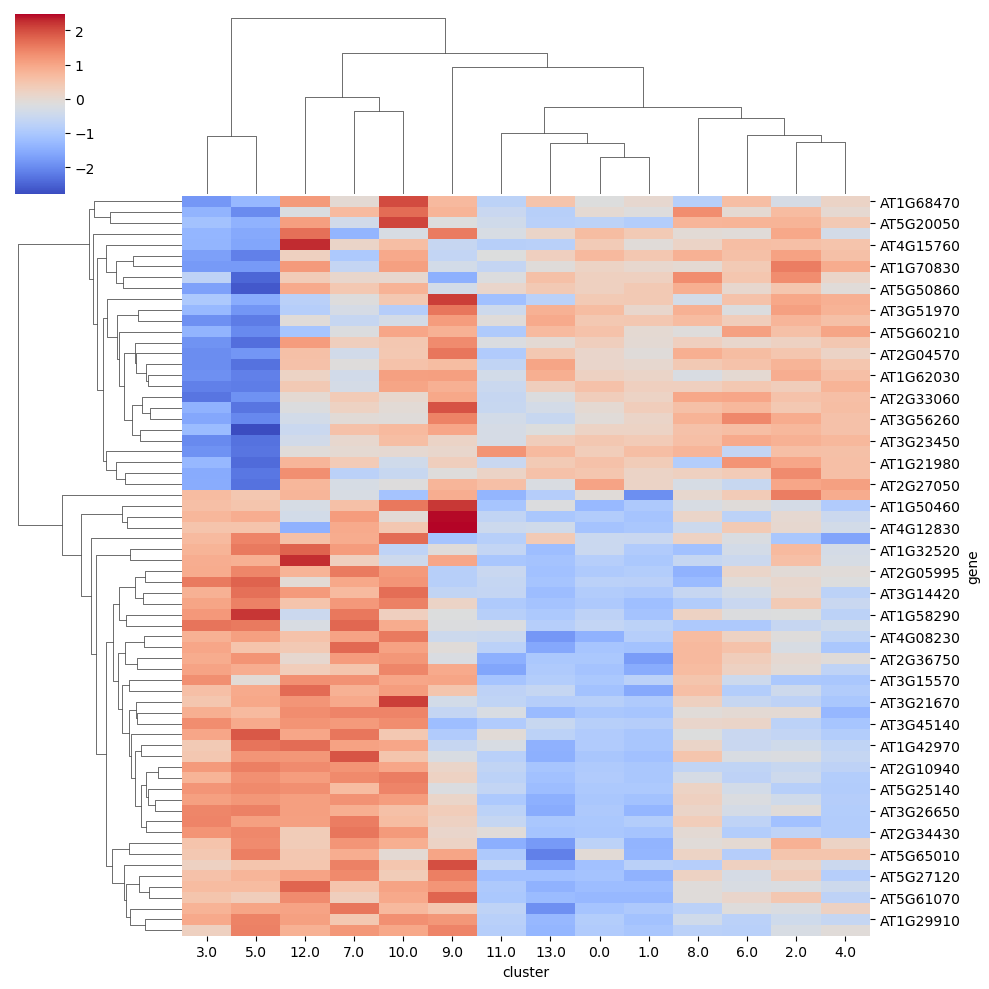

In [49]:
cluster = sns.clustermap(df_zscore.T, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

# plt.title(f'Most Differentially Methylated Genes Clustermap')
plt.savefig('/ceph/MethDev/pbio/kay/figures/0620_highMCClusterMap.pdf')
plt.show()

In [50]:
rna_by_cluster[below_threshold.index]

,AT1G02110,AT1G09160,AT1G11860,AT1G20470,AT1G21980,AT1G23310,AT1G29910,AT1G32520,AT1G42970,AT1G50460,...,AT5G20050,AT5G25140,AT5G27120,AT5G50860,AT5G51460,AT5G53970,AT5G57710,AT5G60210,AT5G61070,AT5G65010
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.133568,31.031634,88.384886,10.690685,11.917399,519.532513,28.588752,48.701230,198.706503,61.231986,...,5.760984,32.047452,80.478032,5.553603,18.479789,60.906854,29.326889,0.920914,2.850615,15.646749
1,2.178756,53.367876,187.717617,6.901554,24.479275,951.352332,77.142487,74.645078,266.331606,102.927461,...,15.000000,76.202073,134.979275,17.111399,19.373057,90.295337,54.911917,0.528497,1.404145,31.538860
2,0.514535,21.279070,35.712209,1.482558,10.340116,169.401163,26.093023,16.886628,60.840116,20.302326,...,1.005814,6.200581,28.465116,12.915698,4.860465,14.851744,21.348837,0.738372,0.000000,7.133721
3,3.044586,21.789809,33.968153,0.748408,49.127389,153.557325,32.500000,19.563694,49.207006,14.831210,...,26.178344,3.713376,38.847134,7.509554,3.621019,9.363057,145.920382,19.671975,0.216561,9.894904
4,1.267477,31.343465,89.905775,1.091185,13.808511,339.440729,49.541033,30.455927,78.370821,49.984802,...,4.659574,12.060790,44.668693,6.781155,10.693009,31.945289,13.343465,0.091185,0.841945,21.033435
5,4.275510,21.178571,35.035714,0.454082,122.066327,112.397959,35.091837,10.867347,39.448980,11.413265,...,38.045918,3.448980,19.821429,26.341837,3.892857,14.015306,175.510204,24.250000,0.020408,6.178571
6,0.768362,70.203390,98.683616,0.293785,28.293785,419.847458,58.175141,24.118644,121.508475,47.819209,...,8.163842,19.807910,48.101695,11.604520,39.169492,41.508475,51.745763,0.220339,1.514124,60.214689
7,1.373418,24.101266,29.278481,0.582278,50.936709,128.949367,33.626582,6.620253,35.563291,33.316456,...,5.063291,1.879747,41.829114,6.449367,0.449367,12.715190,26.202532,0.310127,0.012658,7.037975
8,1.533835,31.834586,40.939850,2.458647,56.781955,205.947368,31.706767,17.187970,53.195489,9.157895,...,6.157895,11.932331,20.812030,1.909774,20.639098,14.571429,7.541353,0.466165,0.030075,16.639098


In [51]:
gene_order = cluster.dendrogram_row.reordered_ind
seurat_order = cluster.dendrogram_col.reordered_ind
thres_rna_df = rna_by_cluster[below_threshold.index]#.drop(columns=[2.0,9.0], axis = 0)
thres_rna_df_reordered = thres_rna_df.iloc[seurat_order,gene_order]

In [52]:
thres_rna_df

,AT1G02110,AT1G09160,AT1G11860,AT1G20470,AT1G21980,AT1G23310,AT1G29910,AT1G32520,AT1G42970,AT1G50460,...,AT5G20050,AT5G25140,AT5G27120,AT5G50860,AT5G51460,AT5G53970,AT5G57710,AT5G60210,AT5G61070,AT5G65010
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.133568,31.031634,88.384886,10.690685,11.917399,519.532513,28.588752,48.701230,198.706503,61.231986,...,5.760984,32.047452,80.478032,5.553603,18.479789,60.906854,29.326889,0.920914,2.850615,15.646749
1,2.178756,53.367876,187.717617,6.901554,24.479275,951.352332,77.142487,74.645078,266.331606,102.927461,...,15.000000,76.202073,134.979275,17.111399,19.373057,90.295337,54.911917,0.528497,1.404145,31.538860
2,0.514535,21.279070,35.712209,1.482558,10.340116,169.401163,26.093023,16.886628,60.840116,20.302326,...,1.005814,6.200581,28.465116,12.915698,4.860465,14.851744,21.348837,0.738372,0.000000,7.133721
3,3.044586,21.789809,33.968153,0.748408,49.127389,153.557325,32.500000,19.563694,49.207006,14.831210,...,26.178344,3.713376,38.847134,7.509554,3.621019,9.363057,145.920382,19.671975,0.216561,9.894904
4,1.267477,31.343465,89.905775,1.091185,13.808511,339.440729,49.541033,30.455927,78.370821,49.984802,...,4.659574,12.060790,44.668693,6.781155,10.693009,31.945289,13.343465,0.091185,0.841945,21.033435
5,4.275510,21.178571,35.035714,0.454082,122.066327,112.397959,35.091837,10.867347,39.448980,11.413265,...,38.045918,3.448980,19.821429,26.341837,3.892857,14.015306,175.510204,24.250000,0.020408,6.178571
6,0.768362,70.203390,98.683616,0.293785,28.293785,419.847458,58.175141,24.118644,121.508475,47.819209,...,8.163842,19.807910,48.101695,11.604520,39.169492,41.508475,51.745763,0.220339,1.514124,60.214689
7,1.373418,24.101266,29.278481,0.582278,50.936709,128.949367,33.626582,6.620253,35.563291,33.316456,...,5.063291,1.879747,41.829114,6.449367,0.449367,12.715190,26.202532,0.310127,0.012658,7.037975
8,1.533835,31.834586,40.939850,2.458647,56.781955,205.947368,31.706767,17.187970,53.195489,9.157895,...,6.157895,11.932331,20.812030,1.909774,20.639098,14.571429,7.541353,0.466165,0.030075,16.639098


In [53]:
thres_rna_df.iloc[seurat_order,gene_order]

,AT1G68470,AT3G50570,AT5G20050,AT5G57710,AT4G15760,AT1G62035,AT1G70830,AT1G78570,AT5G50860,AT1G53500,...,AT2G34430,AT3G61470,AT5G65010,AT2G14560,AT5G27120,AT1G20470,AT5G61070,AT2G26080,AT1G29910,AT3G56940
Cluster,,,,,,,,,,,,,,,,,,,,,
3,14.726115,2.914013,26.178344,145.920382,26.633758,1.958599,33.455414,20.299363,7.509554,40.598726,...,7.076433,26.410828,9.894904,6.388535,38.847134,0.748408,0.216561,33.643312,32.500000,53.910828
5,7.719388,1.081633,38.045918,175.510204,26.642857,8.586735,10.826531,50.688776,26.341837,24.678571,...,12.372449,39.025510,6.178571,0.505102,19.821429,0.454082,0.020408,26.438776,35.091837,44.612245
12,0.019608,0.000000,4.568627,21.274510,0.058824,0.000000,4.176471,19.117647,1.274510,4.117647,...,3.392157,23.470588,14.686275,0.568627,7.588235,0.352941,0.098039,22.686275,39.235294,30.176471
7,3.310127,0.000000,5.063291,26.202532,2.778481,1.050633,7.398734,7.392405,6.449367,19.183544,...,3.974684,31.841772,7.037975,2.392405,41.829114,0.582278,0.012658,45.500000,33.626582,42.721519
10,0.350649,0.129870,1.636364,11.857143,0.090909,0.000000,7.753247,7.740260,0.220779,5.233766,...,1.766234,29.675325,4.246753,7.246753,25.194805,1.051948,0.025974,36.415584,31.233766,32.584416
9,0.000000,0.000000,2.127660,4.872340,0.053191,0.000000,1.680851,1.010638,0.042553,1.989362,...,8.797872,17.265957,3.989362,0.042553,10.553191,0.531915,0.053191,12.691489,22.659574,33.914894
11,1.358974,0.076923,8.551282,23.256410,7.538462,0.000000,27.397436,4.269231,6.974359,26.012821,...,11.858974,87.576923,26.423077,23.371795,54.858974,2.410256,3.487179,101.448718,57.679487,109.089744
13,0.120000,0.000000,25.520000,65.440000,74.120000,0.000000,0.000000,1.720000,9.600000,23.240000,...,14.840000,87.400000,28.640000,236.640000,123.520000,0.760000,0.200000,247.920000,50.320000,84.800000
0,0.096661,0.036907,5.760984,29.326889,15.474517,0.003515,7.989455,2.281195,5.553603,9.279438,...,8.398946,67.033392,15.646749,15.789104,80.478032,10.690685,2.850615,214.869947,28.588752,93.411248


In [54]:
thres_rna_df_reordered_log = thres_rna_df_reordered.applymap(lambda x: np.log2(x + 1e-9))  # Adding a small value to avoid log(0)

In [55]:
rna_zscore_log = thres_rna_df_reordered_log.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
# rna_zscore

In [56]:
rna_zscore = thres_rna_df_reordered.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
# rna_zscore

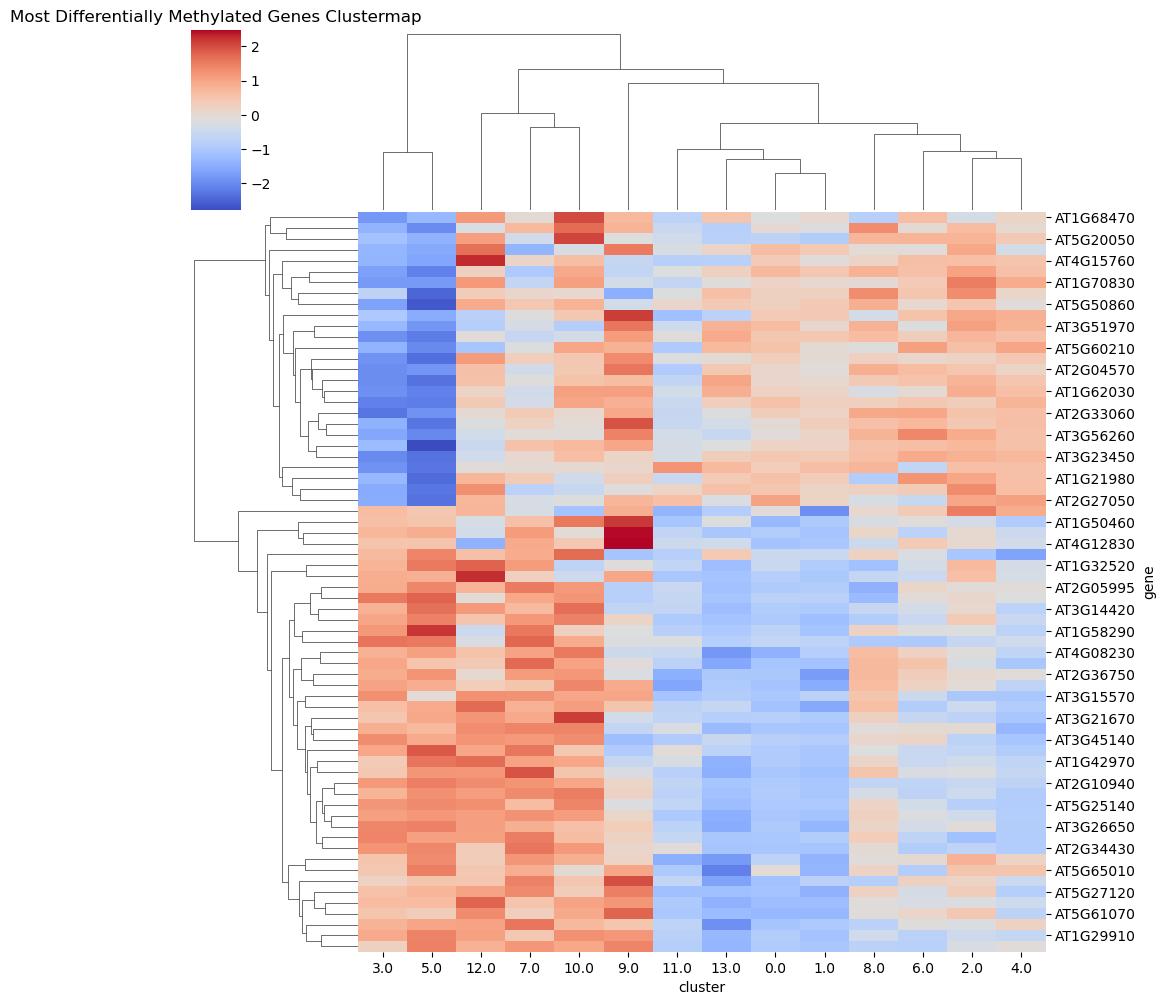

In [57]:
cluster = sns.clustermap(df_zscore.T, method='average', metric='euclidean', cmap='coolwarm', figsize=(10, 10))

plt.title(f'Most Differentially Methylated Genes Clustermap')
# plt.savefig('/ceph/MethDev/pbio/kay/result/highMCClusterMap.pdf')
plt.show()

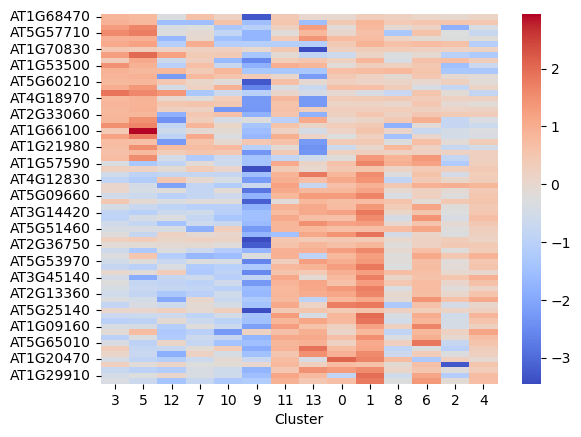

In [58]:
sns.heatmap(rna_zscore_log.T,cmap = 'coolwarm')
plt.savefig('/ceph/MethDev/pbio/kay/figures/0620_highMCRNAClusterMap.pdf')

<AxesSubplot:xlabel='Cluster'>

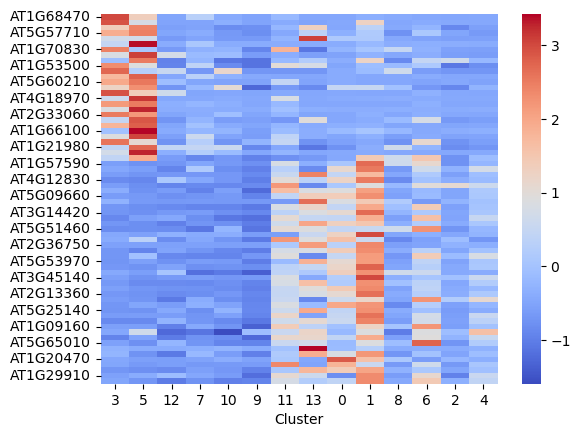

In [59]:
sns.heatmap(rna_zscore.T,cmap = 'coolwarm')
